<a href="https://colab.research.google.com/github/priyav23116/sentiment-analysis-using-deep-learning-/blob/main/Copy_of_Copy_of_Sentiment_analysis_using_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 347ms/step - accuracy: 0.7614 - loss: 0.4850 - val_accuracy: 0.8540 - val_loss: 0.3519
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 339ms/step - accuracy: 0.8986 - loss: 0.2614 - val_accuracy: 0.8652 - val_loss: 0.3204
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 340ms/step - accuracy: 0.9298 - loss: 0.1908 - val_accuracy: 0.8724 - val_loss: 0.3304
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8649 - loss: 0.3456
Test Accuracy: 0.8649200201034546


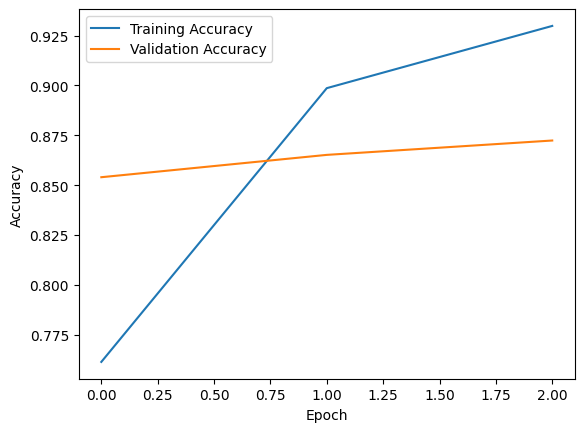

Model saved successfully!


In [ ]:
# Inst6all TensorFlow (usually already available in Colab)
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load dataset
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build model
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Plot training curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Save model
model.save("sentiment_model.h5")

print("Model saved successfully!")